# 3.1 Pengumpulan Data

In [ ]:
import pandas as pd

# Memuat dataset yang sudah diupload
df = pd.read_csv('/content/film_dataset.csv')

# Filter film yang dirilis antara tahun 2010 dan 2020
filtered_df = df[(df['startYear'] >= 2010) & (df['startYear'] <= 2020)]

# Menampilkan jumlah data yang difilter
print(f"Jumlah film yang dirilis antara 2010 dan 2020: {filtered_df.shape[0]}")

# Menampilkan beberapa baris pertama dari data yang sudah difilter
filtered_df.head()

Jumlah film yang dirilis antara 2010 dan 2020: 1622


,tconst,primaryTitle,startYear,rank,averageRating,numVotes,runtimeMinutes,directors,writers,genres,IMDbLink,Title_IMDb_Link
9,tt1375666,Inception,2010,10,8.8,2675889,148,Christopher Nolan,Christopher Nolan,"Action, Adventure, Sci-Fi","<a href=""https://www.imdb.com/title/tt1375666""...","<a href=""https://www.imdb.com/title/tt1375666""..."
14,tt0816692,Interstellar,2014,15,8.7,2335457,169,Christopher Nolan,"Jonathan Nolan, Christopher Nolan","Adventure, Drama, Sci-Fi","<a href=""https://www.imdb.com/title/tt0816692""...","<a href=""https://www.imdb.com/title/tt0816692""..."
30,tt1853728,Django Unchained,2012,31,8.5,1786173,165,Quentin Tarantino,Quentin Tarantino,Western,"<a href=""https://www.imdb.com/title/tt1853728""...","<a href=""https://www.imdb.com/title/tt1853728""..."
39,tt2582802,Whiplash,2014,40,8.5,1070213,106,Damien Chazelle,Damien Chazelle,"Drama, Music","<a href=""https://www.imdb.com/title/tt2582802""...","<a href=""https://www.imdb.com/title/tt2582802""..."
40,tt6751668,Parasite,2019,41,8.5,1057180,132,Bong Joon Ho,"Bong Joon Ho, Han Jin-won","Drama, Thriller","<a href=""https://www.imdb.com/title/tt6751668""...","<a href=""https://www.imdb.com/title/tt6751668""..."


# 3.2 Pre processing Data

In [ ]:
# tipe data setiap kolom
filtered_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1622 entries, 9 to 4992
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           1622 non-null   object 
 1   primaryTitle     1622 non-null   object 
 2   startYear        1622 non-null   int64  
 3   rank             1622 non-null   int64  
 4   averageRating    1622 non-null   float64
 5   numVotes         1622 non-null   int64  
 6   runtimeMinutes   1622 non-null   int64  
 7   directors        1622 non-null   object 
 8   writers          1605 non-null   object 
 9   genres           1622 non-null   object 
 10  IMDbLink         1622 non-null   object 
 11  Title_IMDb_Link  1622 non-null   object 
dtypes: float64(1), int64(4), object(7)
memory usage: 164.7+ KB


In [ ]:
selected_columns = {'startYear': 'Year_Release', 'runtimeMinutes': 'Duration', 'genres': 'Genres', 'averageRating': 'Rating'}

df_cleaned = filtered_df[list(selected_columns.keys())].rename(columns=selected_columns)
df_cleaned = df_cleaned.reset_index(drop=True) #dinomorin dari 0

In [ ]:
df_cleaned.head()

,Year_Release,Duration,Genres,Rating
0,2010,148,"Action, Adventure, Sci-Fi",8.8
1,2014,169,"Adventure, Drama, Sci-Fi",8.7
2,2012,165,Western,8.5
3,2014,106,"Drama, Music",8.5
4,2019,132,"Drama, Thriller",8.5


In [ ]:
df_cleaned.tail()

,Year_Release,Duration,Genres,Rating
1617,2010,107,"Action, Crime, Drama",6.2
1618,2019,115,"Action, Crime, Mystery",6.2
1619,2016,89,"Horror, Thriller",6.2
1620,2010,94,"Comedy, Drama, Family",6.2
1621,2010,107,"Drama, Music, Romance",6.2


In [ ]:
# Hitung jumlah film panjang (durasi > 40 menit)
film_panjang = df_cleaned[df_cleaned['Duration'] > 40].shape[0]

# Hitung jumlah film pendek (durasi <= 40 menit)
film_pendek = df_cleaned[df_cleaned['Duration'] <= 40].shape[0]

# Tampilkan hasil
print(f"Jumlah film dengan durasi > 40 menit: {film_panjang}")
print(f"Jumlah film dengan durasi <= 40 menit: {film_pendek}")

Jumlah film dengan durasi > 40 menit: 1622
Jumlah film dengan durasi <= 40 menit: 0


In [ ]:
# Mengecek jumlah missing value di setiap kolom
print("Jumlah missing value sebelum dibersihkan:")
print(df_cleaned.isnull().sum())

Jumlah missing value sebelum dibersihkan:
Year_Release    0
Duration        0
Genres          0
Rating          0
dtype: int64


In [ ]:
# Mengecek jumlah baris duplikat
jumlah_duplikat = df_cleaned.duplicated().sum()
print(f"Jumlah data duplikat: {jumlah_duplikat}")

Jumlah data duplikat: 3


In [ ]:
# Menampilkan semua baris yang terduplikasi (termasuk yang pertama)
semua_duplikat = df_cleaned[df_cleaned.duplicated(keep=False)]
print("Semua kemunculan data yang duplikat:")
print(semua_duplikat)

Semua kemunculan data yang duplikat:
     Year_Release  Duration                        Genres  Rating
124          2014       102  Action, Adventure, Animation     7.8
132          2014       102  Action, Adventure, Animation     7.8
469          2011       107  Action, Adventure, Animation     7.3
476          2011       107  Action, Adventure, Animation     7.3
518          2014       102         Crime, Drama, Mystery     7.4
520          2014       102         Crime, Drama, Mystery     7.4


In [ ]:
# Pastikan indeks yang Anda pilih ada dalam rentang jumlah baris DataFrame
print(len(df_cleaned))  # Mengetahui jumlah baris pada DataFrame

# Kemudian menampilkan baris yang diinginkan, misalnya baris 443, 459, 1709, 1729, 11858, dan 1864
filtered_df.iloc[[124, 132, 469, 476, 518, 520]],[['primaryTitle', 'startYear', 'runtimeMinutes', 'Genres', 'averageRating']]

1622


(         tconst                primaryTitle  startYear  rank  averageRating  \
 443   tt2245084                  Big Hero 6       2014   444            7.8   
 459   tt1646971  How to Train Your Dragon 2       2014   460            7.8   
 1709  tt1192628                       Rango       2011  1710            7.3   
 1729  tt0983193    The Adventures of Tintin       2011  1730            7.3   
 1858  tt2234003                     Calvary       2014  1859            7.4   
 1864  tt3042408                    Who Am I       2014  1865            7.4   
 
       numVotes  runtimeMinutes                 directors  \
 443     527995             102  Don Hall, Chris Williams   
 459     380570             102              Dean DeBlois   
 1709    304627             107            Gore Verbinski   
 1729    248921             107          Steven Spielberg   
 1858     66254             102     John Michael McDonagh   
 1864     64850             102             Baran bo Odar   
 
         

In [ ]:
# Menghapus baris duplikat berdasarkan kolom yang digunakan untuk pemodelan
df_cleaned = df_cleaned.drop_duplicates()
print(f"Jumlah data setelah menghapus duplikat: {df_cleaned.shape[0]}")

Jumlah data setelah menghapus duplikat: 1619


In [ ]:
print("Cek missing value:")
print(df_cleaned.isnull().sum())

Cek missing value:
Year_Release    0
Duration        0
Genres          0
Rating          0
dtype: int64


Encoding merupakan proses yang mengubah data kategorikal menjadi data numerik yang dapat dipahami oleh algoritma machine learning.

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# Ubah kolom 'Genres' menjadi list dan bersihkan spasi
df_cleaned['Genres'] = df_cleaned['Genres'].apply(lambda x: [g.strip() for g in x.split(',')])

# Lakukan encoding
mlb = MultiLabelBinarizer()
genre_encoded = pd.DataFrame(mlb.fit_transform(df_cleaned['Genres']),
                             columns=mlb.classes_,
                             index=df_cleaned.index)

# Gabungkan dengan data asli
df_encoded = pd.concat([df_cleaned.drop(columns='Genres'), genre_encoded], axis=1)

# Tampilkan hasil
print(df_encoded.head().to_string(index=False))

 Year_Release  Duration  Rating  Action  Adventure  Animation  Biography  Comedy  Crime  Documentary  Drama  Family  Fantasy  History  Horror  Music  Musical  Mystery  News  Romance  Sci-Fi  Sport  Thriller  War  Western
         2010       148     8.8       1          1          0          0       0      0            0      0       0        0        0       0      0        0        0     0        0       1      0         0    0        0
         2014       169     8.7       0          1          0          0       0      0            0      1       0        0        0       0      0        0        0     0        0       1      0         0    0        0
         2012       165     8.5       0          0          0          0       0      0            0      0       0        0        0       0      0        0        0     0        0       0      0         0    0        1
         2014       106     8.5       0          0          0          0       0      0            0      1       0 

/tmp/ipython-input-14-2056761032.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cleaned['Genres'] = df_cleaned['Genres'].apply(lambda x: [g.strip() for g in x.split(',')])


In [ ]:
print(df_cleaned['Genres'].head(10))
print(df_cleaned['Genres'].apply(type).value_counts())

0    [Action, Adventure, Sci-Fi]
1     [Adventure, Drama, Sci-Fi]
2                      [Western]
3                 [Drama, Music]
4              [Drama, Thriller]
5                [Comedy, Drama]
6                        [Drama]
7         [Action, Crime, Drama]
8    [Action, Adventure, Sci-Fi]
9    [Action, Adventure, Sci-Fi]
Name: Genres, dtype: object
Genres
<class 'list'>    1619
Name: count, dtype: int64


In [ ]:
# Melihat tipe data seluruh kolom di df_encoded
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1619 entries, 0 to 1621
Data columns (total 25 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Year_Release  1619 non-null   int64  
 1   Duration      1619 non-null   int64  
 2   Rating        1619 non-null   float64
 3   Action        1619 non-null   int64  
 4   Adventure     1619 non-null   int64  
 5   Animation     1619 non-null   int64  
 6   Biography     1619 non-null   int64  
 7   Comedy        1619 non-null   int64  
 8   Crime         1619 non-null   int64  
 9   Documentary   1619 non-null   int64  
 10  Drama         1619 non-null   int64  
 11  Family        1619 non-null   int64  
 12  Fantasy       1619 non-null   int64  
 13  History       1619 non-null   int64  
 14  Horror        1619 non-null   int64  
 15  Music         1619 non-null   int64  
 16  Musical       1619 non-null   int64  
 17  Mystery       1619 non-null   int64  
 18  News          1619 non-null   int

# 3.3 Eksplorisasi dan visualisasi data

### 1. Boxplot: Sebaran rating berdasarkan genre


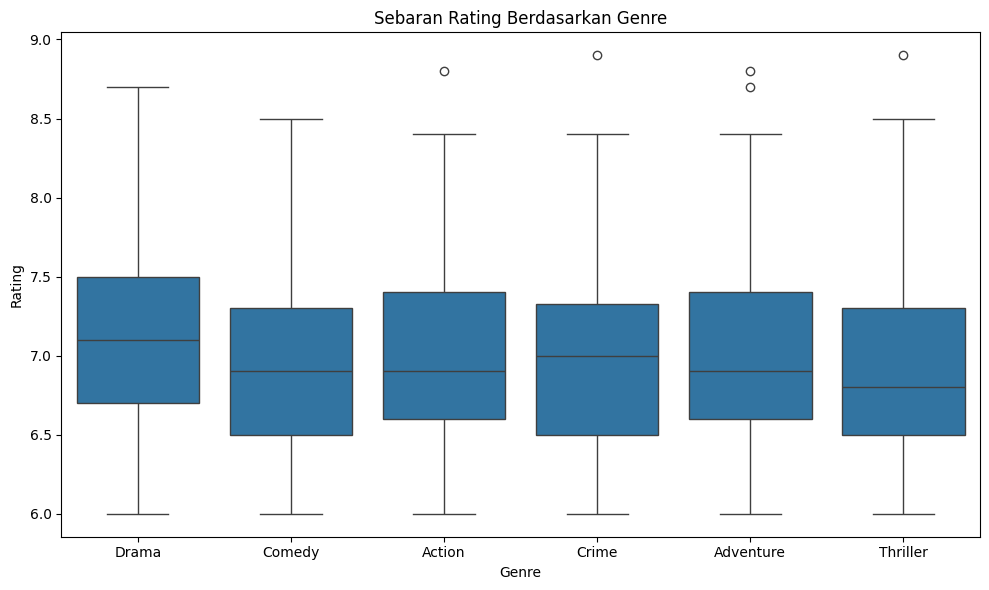

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat boxplot untuk setiap genre (pilih genre populer agar tidak terlalu ramai)
genre_cols = df_encoded.columns[3:]  # genre dimulai dari kolom ke-3
top_Genres = df_encoded[genre_cols].sum().sort_values(ascending=False).head(6).index

# Buat boxplot hanya untuk genre teratas
plt.figure(figsize=(10, 6))
df_melt = df_encoded.melt(id_vars=['Rating'], value_vars=top_Genres)
df_melt = df_melt[df_melt['value'] == 1]

sns.boxplot(x='variable', y='Rating', data=df_melt)
plt.title('Sebaran Rating Berdasarkan Genre')
plt.xlabel('Genre')
plt.ylabel('Rating')
plt.tight_layout()
plt.show()

Visualisasi ini menunjukkan distribusi nilai rating IMDb dari beberapa genre film yang paling sering muncul seperti Drama, Comedy, Action, Crime, Adventure, dan Thriller.
* Drama tampak memiliki sebaran rating yang lebih luas, dengan median di atas 7.0, dan beberapa nilai outlier yang tinggi (mendekati 9.0).
* Genre seperti Comedy dan Action memiliki median yang sedikit lebih rendah dibanding Drama, tetapi tetap berada pada kisaran 6.5–7.0.
* Sebagian besar genre menunjukkan bahwa mayoritas film memiliki rating antara 6.0 hingga 8.0, yang menandakan bahwa persepsi penonton terhadap berbagai genre cukup merata.
* Tidak ada satu genre pun yang memiliki dominasi ekstrem dalam hal nilai rating, yang mengindikasikan bahwa kualitas film tidak hanya ditentukan oleh genre.


### 2. Scatter plot: Korelasi antara durasi dan rating

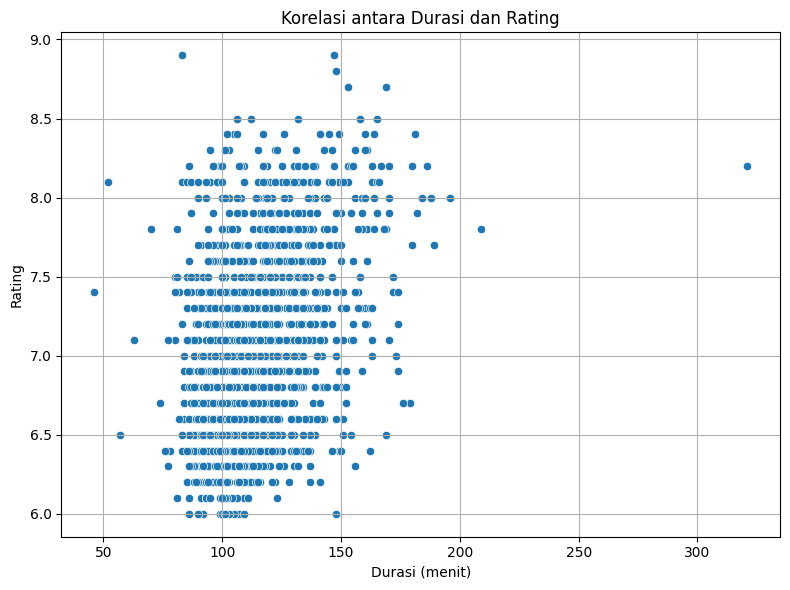

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_encoded, x='Duration', y='Rating')
plt.title('Korelasi antara Durasi dan Rating')
plt.xlabel('Durasi (menit)')
plt.ylabel('Rating')
plt.grid(True)
plt.tight_layout()
plt.show()

Scatter plot ini menampilkan hubungan antara variabel numerik durasi film (runtimeMinutes) dan averageRating.
* Titik-titik tersebar cukup luas, dan tidak menunjukkan pola korelasi yang jelas antara durasi dan rating.
* Sebagian besar film memiliki durasi antara 90 hingga 150 menit, yang merupakan panjang film umum.
* Film dengan durasi di luar kisaran tersebut tidak serta-merta memiliki rating lebih tinggi atau lebih rendah, yang berarti durasi tidak memiliki pengaruh kuat secara langsung terhadap rating.
* Kesimpulan sementaranya adalah durasi film memiliki korelasi yang lemah terhadap rating dan mungkin bukan faktor utama dalam penilaian kualitas film oleh pengguna IMDb.

### 3. Line chart: Tren rating dari tahun ke tahun

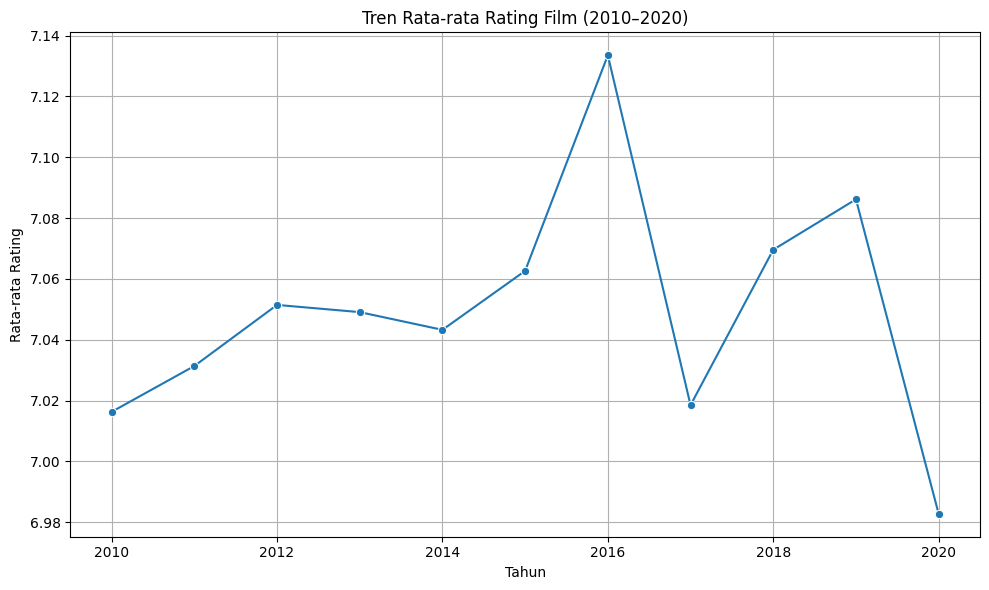

In [ ]:
# Hitung rata-rata rating tiap tahun
rating_by_year = df_encoded.groupby('Year_Release')['Rating'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.lineplot(data=rating_by_year, x='Year_Release', y='Rating', marker='o')
plt.title('Tren Rata-rata Rating Film (2010–2020)')
plt.xlabel('Tahun')
plt.ylabel('Rata-rata Rating')
plt.grid(True)
plt.tight_layout()
plt.show()

Grafik ini menggambarkan perubahan rata-rata rating film dari tahun ke tahun dalam rentang 2010 hingga 2020.
* Secara umum, tren terlihat stabil dengan sedikit fluktuasi. Rata-rata rating film setiap tahun berkisar antara 7.0 hingga 7.1.
* Tahun 2016 menunjukkan puncak tertinggi dalam rata-rata rating, sementara 2020 justru menjadi tahun dengan rata-rata rating terendah.
* Penurunan tajam pada tahun 2020 kemungkinan dipengaruhi oleh faktor eksternal seperti pandemi COVID-19 yang memengaruhi industri film secara global, baik dari segi produksi maupun preferensi penonton.

# 3.4 Analisis Regresi linier berganda

### Analisis regresi linier berganda menggunakan data yang sudah diproses (yang telah melalui tahapan pembersihan, encoding genre, dan pemilihan variabel numerik).

🎯 Tujuan

Untuk mengetahui pengaruh variabel independen:
* runtimeMinutes (durasi film),
* dan masing-masing variabel genre (hasil dari encoding),

terhadap variabel dependen:
* averageRating (rating film di IMDb).

## ✅ Langkah-langkah Analisis Regresi Linier Berganda (dengan Python)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Tentukan variabel X (independen) dan y (dependen)
X = df_encoded.drop(columns='Rating')  # Semua kolom kecuali rating
y = df_encoded['Rating']               # Target variabel

# 2. Split data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Bangun model regresi linier
model = LinearRegression()
model.fit(X_train, y_train)

# 4. Prediksi
y_pred = model.predict(X_test)

# 5. Evaluasi model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 6. Tampilkan hasil
print("Koefisien determinasi (R^2):", round(r2, 4))
print("Mean Squared Error (MSE):", round(mse, 4))
print("\nKoefisien untuk masing-masing variabel:")
for col, coef in zip(X.columns, model.coef_):
    print(f"{col}: {round(coef, 4)}")

Koefisien determinasi (R^2): 0.2359
Mean Squared Error (MSE): 0.2408

Koefisien untuk masing-masing variabel:
Year_Release: -0.01
Duration: 0.0126
Action: -0.1788
Adventure: -0.1077
Animation: 0.3671
Biography: -0.0443
Comedy: -0.1003
Crime: -0.1566
Documentary: 0.9476
Drama: 0.0871
Family: -0.161
Fantasy: -0.1513
History: -0.1652
Horror: -0.2814
Music: -0.1002
Musical: -0.2637
Mystery: -0.0736
News: 0.3072
Romance: -0.214
Sci-Fi: -0.0289
Sport: -0.1286
Thriller: -0.0735
War: 0.1982
Western: -0.0548


### Interpretasi Hasil Regresi Linier Berganda

1. **Koefisien Determinasi (R² = 0.2359)**
   Ini berarti bahwa sekitar **23,59% variasi dalam *rating* film dapat dijelaskan** oleh variabel-variabel independen dalam model, yaitu *year\_release*, *duration*, dan semua genre yang telah diencoding. Meskipun nilai ini menunjukkan bahwa model dapat menjelaskan sebagian variasi rating, **masih ada sekitar 76,41% variasi yang tidak dijelaskan**, kemungkinan karena faktor lain yang tidak disertakan dalam model (seperti aktor, studio produksi, ulasan pengguna, dll.).

2. **Mean Squared Error (MSE = 0.2408)**
   MSE mengukur seberapa jauh prediksi model berbeda dari nilai sebenarnya. Nilai ini tidak negatif dan semakin kecil semakin baik. Dalam konteks ini, model memprediksi rating dengan **kesalahan kuadrat rata-rata sebesar 0.24**, yang bisa dianggap moderat tergantung pada skala rating IMDb (1–10).

3. **Koefisien Masing-Masing Variabel**
   Nilai koefisien menunjukkan arah dan besarnya pengaruh variabel terhadap *rating*:

   * **Durasi (Duration = 0.0126):** Berdampak positif kecil, artinya semakin lama film, cenderung semakin tinggi rating-nya.
   * **Year Release (-0.01):** Berdampak negatif sangat kecil, artinya film yang lebih baru cenderung sedikit lebih rendah ratingnya, namun pengaruhnya kecil.
   * **Genre dengan Pengaruh Positif Tinggi:**

     * *Documentary (0.9476)*: Memiliki pengaruh terbesar terhadap peningkatan rating.
     * *Animation (0.3671)* dan *News (0.3072)* juga berkontribusi positif.
   * **Genre dengan Pengaruh Negatif Signifikan:**

     * *Horror (-0.2814)*, *Musical (-0.2637)*, *Romance (-0.214)*, dan *Action (-0.1788)*: cenderung menurunkan rating.

   Artinya, jika sebuah film bergenre *Documentary*, memiliki durasi lebih panjang, dan bukan bergenre *Horror* atau *Romance*, kemungkinan memiliki rating lebih tinggi.

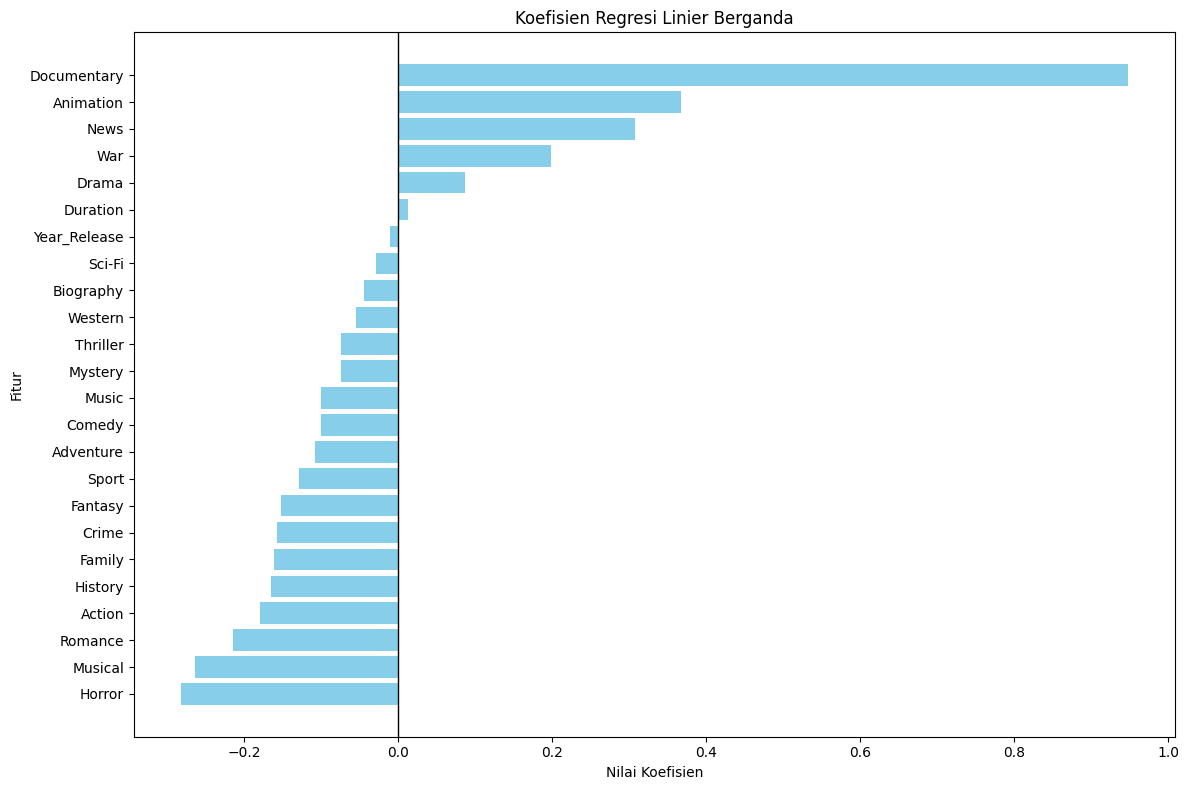

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd

# Ambil nama kolom dan koefisien dari model
coef_df = pd.DataFrame({
    'Fitur': X.columns,
    'Koefisien': model.coef_
})

# Urutkan berdasarkan koefisien
coef_df = coef_df.sort_values(by='Koefisien')

# Plot horizontal bar chart
plt.figure(figsize=(12, 8))
plt.barh(coef_df['Fitur'], coef_df['Koefisien'], color='skyblue')
plt.axvline(0, color='black', linewidth=1)
plt.title('Koefisien Regresi Linier Berganda')
plt.xlabel('Nilai Koefisien')
plt.ylabel('Fitur')
plt.tight_layout()
plt.show()

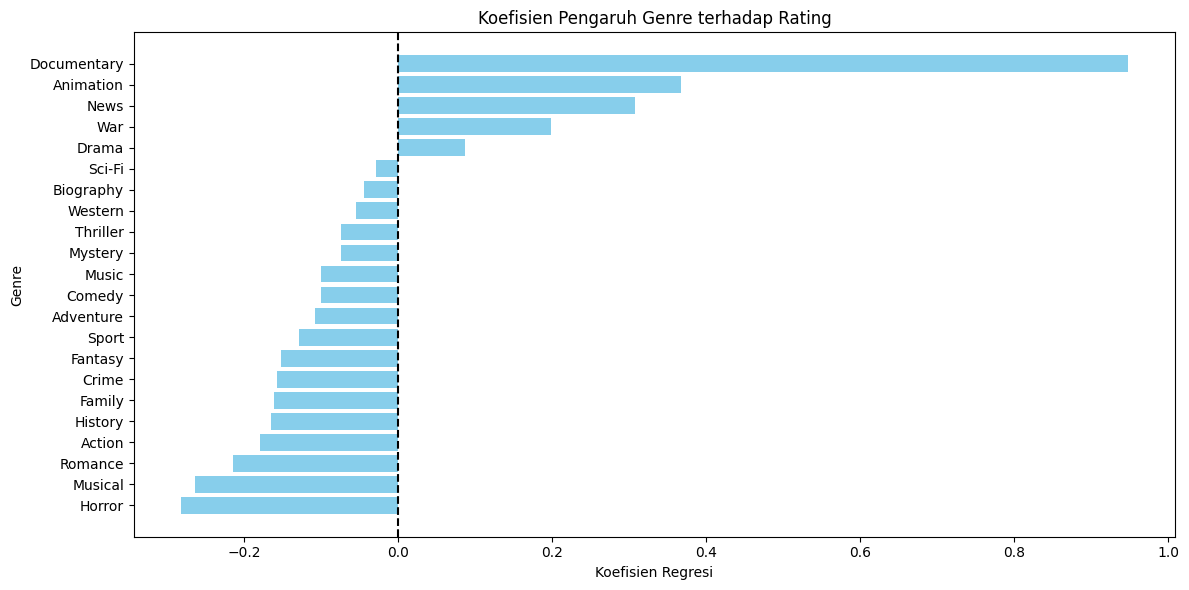

In [ ]:
import matplotlib.pyplot as plt

# Koefisien regresi
coef_dict = {
    'startYear': -0.01,
    'runtimeMinutes': 0.0126,
    'Action': -0.1788,
    'Adventure': -0.1077,
    'Animation': 0.3671,
    'Biography': -0.0443,
    'Comedy': -0.1003,
    'Crime': -0.1566,
    'Documentary': 0.9476,
    'Drama': 0.0871,
    'Family': -0.161,
    'Fantasy': -0.1513,
    'History': -0.1652,
    'Horror': -0.2814,
    'Music': -0.1002,
    'Musical': -0.2637,
    'Mystery': -0.0736,
    'News': 0.3072,
    'Romance': -0.214,
    'Sci-Fi': -0.0289,
    'Sport': -0.1286,
    'Thriller': -0.0735,
    'War': 0.1982,
    'Western': -0.0548
}

# Hapus variabel numerik (opsional, agar fokus genre)
genre_only = {k: v for k, v in coef_dict.items() if k not in ['startYear', 'runtimeMinutes']}

# Urutkan berdasarkan nilai koefisien
sorted_coef = dict(sorted(genre_only.items(), key=lambda item: item[1]))

# Plot
plt.figure(figsize=(12,6))
plt.barh(list(sorted_coef.keys()), list(sorted_coef.values()), color='skyblue')
plt.title('Koefisien Pengaruh Genre terhadap Rating')
plt.xlabel('Koefisien Regresi')
plt.ylabel('Genre')
plt.axvline(x=0, color='black', linestyle='--')
plt.tight_layout()
plt.show()